1. RF classifier (RandomizedSearchCV hyperparameter tuning)
2. Y2H degree centrality percentile 

In [10]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, pearsonr
from tqdm import trange
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
import shap

#DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../../flatten/processed-data/"
#DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"
MS_COLOR_LIGHT = "#EECC66" #color for static (in complex)
MS_COLOR_DARK  = "#997700" #color for dynamic (not in complex)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [11]:
# load the datasets with node centrality information and get nodes in both
#ms_nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")
#y2h_nodes = pd.read_csv(f"{DATA_PATH3}Y2H-s288c-step18.csv")
nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")

# --- Flip sign of cagiada-dG ---
nodes["cagiada-dG"] = -nodes["cagiada-dG"]

# CHAPERONE CATEGORY: three-way classification ===
def fix_list(val):
    if isinstance(val, list):
        return val
    elif isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    elif pd.isnull(val):
        return []
    else:
        return []

nodes['interacting_chaperones'] = nodes['interacting_chaperones'].apply(fix_list)

def chaperone_category(row):
    node = row['node']
    chaps = row['interacting_chaperones']
    if not chaps or chaps == []:
        return 'protein_is_neither_chaperone_nor_interacts'
    elif node in chaps:
        return 'protein_is_chaperone'
    else:
        return 'protein_interacts_with_chaperone'

nodes['chaperone_category'] = nodes.apply(chaperone_category, axis=1)

# ONE-HOT ENCODE CHAPERONE CATEGORY
nodes['is_chaperone'] = (nodes['chaperone_category'] == 'protein_is_chaperone').astype(int)
nodes['interacts_with_chaperone'] = (nodes['chaperone_category'] == 'protein_interacts_with_chaperone').astype(int)
nodes['neither_chaperone_nor_interacts'] = (nodes['chaperone_category'] == 'protein_is_neither_chaperone_nor_interacts').astype(int)

#y2h_nodes = y2h_nodes.merge(abundance_df, on="node", how="left")

#shared_nodes = set(ms_nodes["node"]) & set(y2h_nodes["node"])
#print (f"A total of {len(shared_nodes)} nodes are shared between the MS and Y2H networks")
#list(nodes.columns)

In [12]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")


Original rows: 3927
Filtered rows: 2466


In [13]:
# determine which nodes are hubs based on percentile cutoff for betweenness centrality
cut = 0.10
#ms_threshold = filtered_nodes['betweenness_centrality'].quantile(1 - cut)
#ms_hubs     = filtered_nodes[filtered_nodes['betweenness_centrality'] >= ms_threshold]
#ms_nothub   = filtered_nodes[filtered_nodes['betweenness_centrality'] <  ms_threshold]

y2h_threshold = filtered_nodes['Y2H_degree_centrality'].quantile(1 - cut)
y2h_hubs      = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] >= y2h_threshold]
y2h_nothub    = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] <  y2h_threshold]

#print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in Y2H data is 0.00297; there are 116 hubs and 866 non hubs


In [14]:
# SCRIPT 2: Feature & Target Preparation
# Create target column if not already created
filtered_nodes['y2h_hubs'] = (filtered_nodes['Y2H_degree_centrality'] >= y2h_threshold).astype(int)

# 2. Feature & Target Preparation
ml_features = [
    'Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score',
    'Villen_halflife_min',
    'mean_molecules_per_cell',
    'interacts_with_chaperone', 'in_complex',
    'essential',
    'meltome-melting-point', 'N_aa_disordered', 'disorder_fraction', 'mean_plddt'
]

X = filtered_nodes[ml_features].copy()
y = filtered_nodes['y2h_hubs'].copy()

# Replace common string indicators of missing values with NaN, then convert to numeric
missing_indicators = [
    'n.d.', 'N.D.', 'nd', 'ND', 'na', 'NA', 'null', 'NULL',
    'missing', 'MISSING', '-', 'n/a', 'N/A', ''
]

for col in ml_features:
    X[col] = X[col].replace(missing_indicators, np.nan)
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill remaining NaNs with -999 (important for sklearn RF)
X_filled = X.fillna(-999)

print("✅ Data preparation complete")
print(f"Total usable samples: {len(X_filled)}")

✅ Data preparation complete
Total usable samples: 2466


Data split completed:
Training set: 1972 samples
Test set: 494 samples
Training class ratio: 4.7% high PME
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 10, 'class_weight': 'balanced'}
Random Forest model trained

Model Performance:
Balanced Accuracy: 0.494
Precision: 0.000
Recall: 0.000
F1-Score: 0.000
ROC-AUC: 0.661

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       471
           1       0.00      0.00      0.00        23

    accuracy                           0.94       494
   macro avg       0.48      0.49      0.48       494
weighted avg       0.91      0.94      0.92       494


Confusion Matrix:
TP: 0, FP: 6, TN: 465, FN: 23
True Positive Rate (Recall): 0.000
False Positive Rate: 0.013

Computing SHAP values...


/tmp/ipykernel_9487/204858649.py:119: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


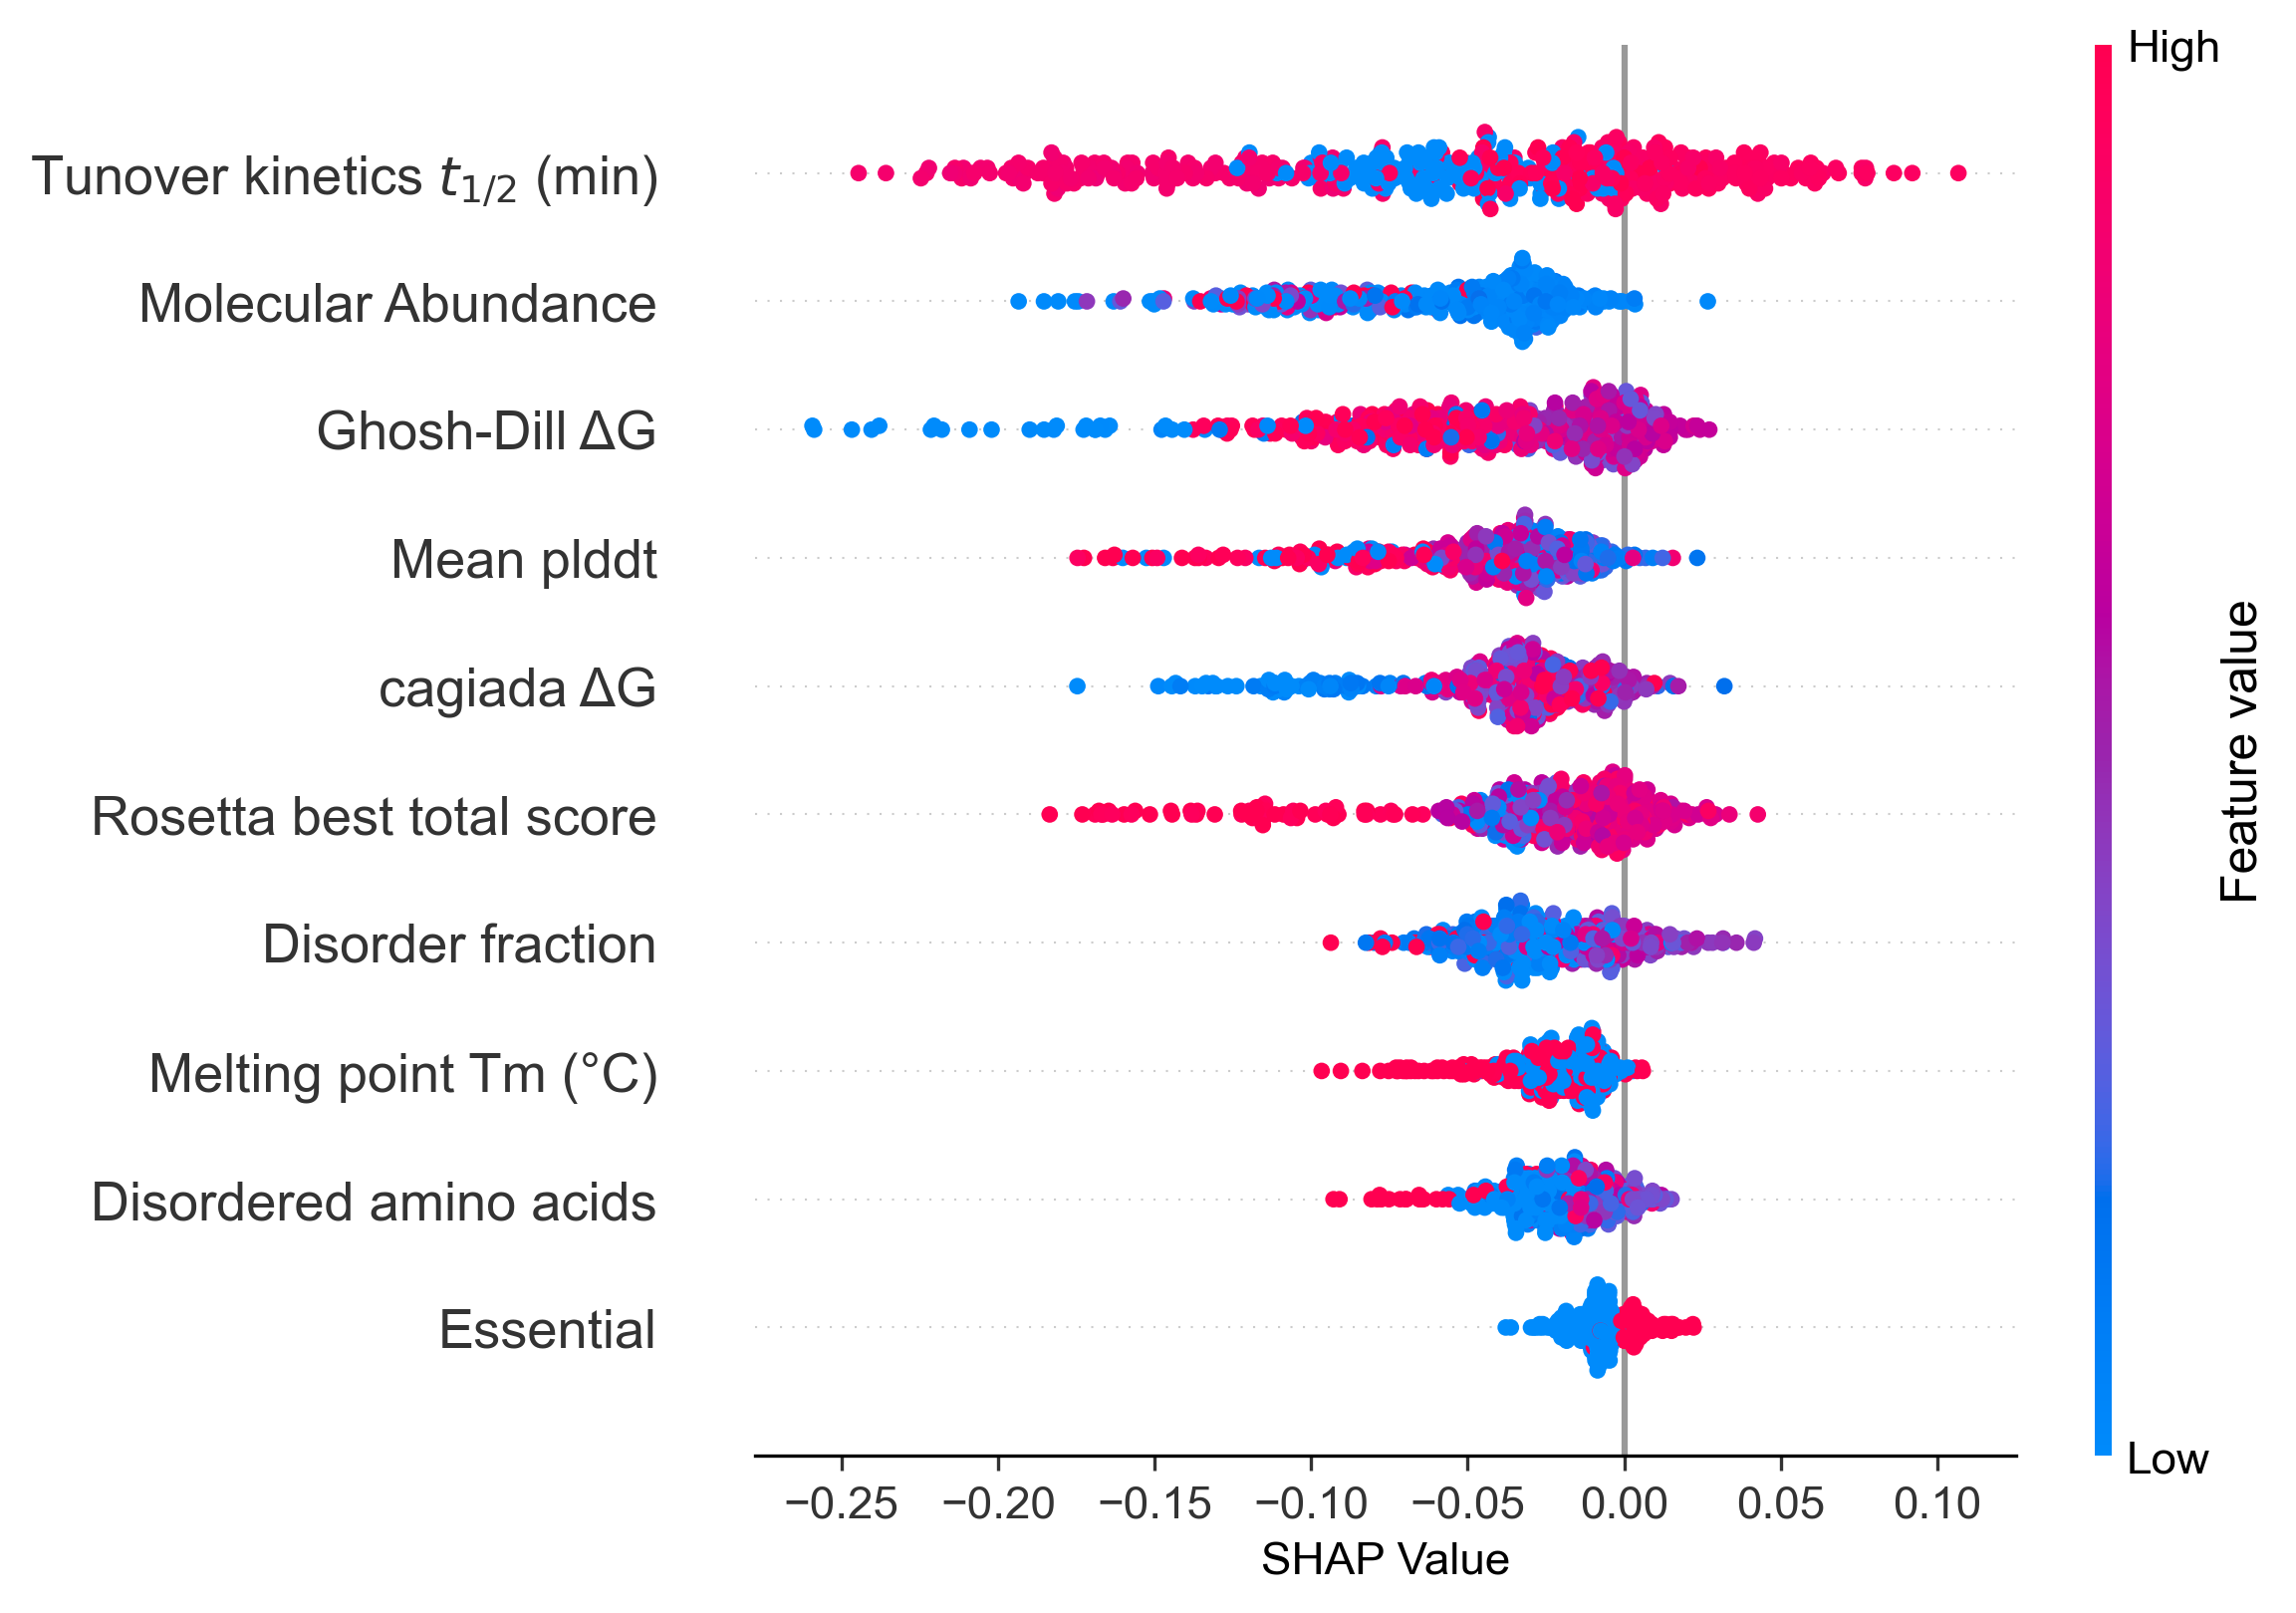


Random Forest Gini-based Feature Importances:
                         Feature  Gini Importance
             Molecular Abundance         0.154439
Tunover kinetics $t_{1/2}$ (min)         0.147942
                   Ghosh-Dill ΔG         0.125600
                      Mean plddt         0.119188
                      cagiada ΔG         0.108419
        Rosetta best total score         0.102609
               Disorder fraction         0.078174
           Melting point Tm (°C)         0.062638
          Disordered amino acids         0.058054
                       Essential         0.017655
               Complex formation         0.014280
           Chaperone interaction         0.011000

Generating comprehensive ROC data for Origin plotting...
ROC Data Generated:
Total data points: 51
AUC Score: 0.661405
FPR range: 0.000000 to 1.000000
TPR range: 0.000000 to 1.000000
Threshold range: 0.000000 to inf

Complete ROC Data (Copy-Paste Ready for Origin):
# ROC Curve Data
# False_Positive_Ra

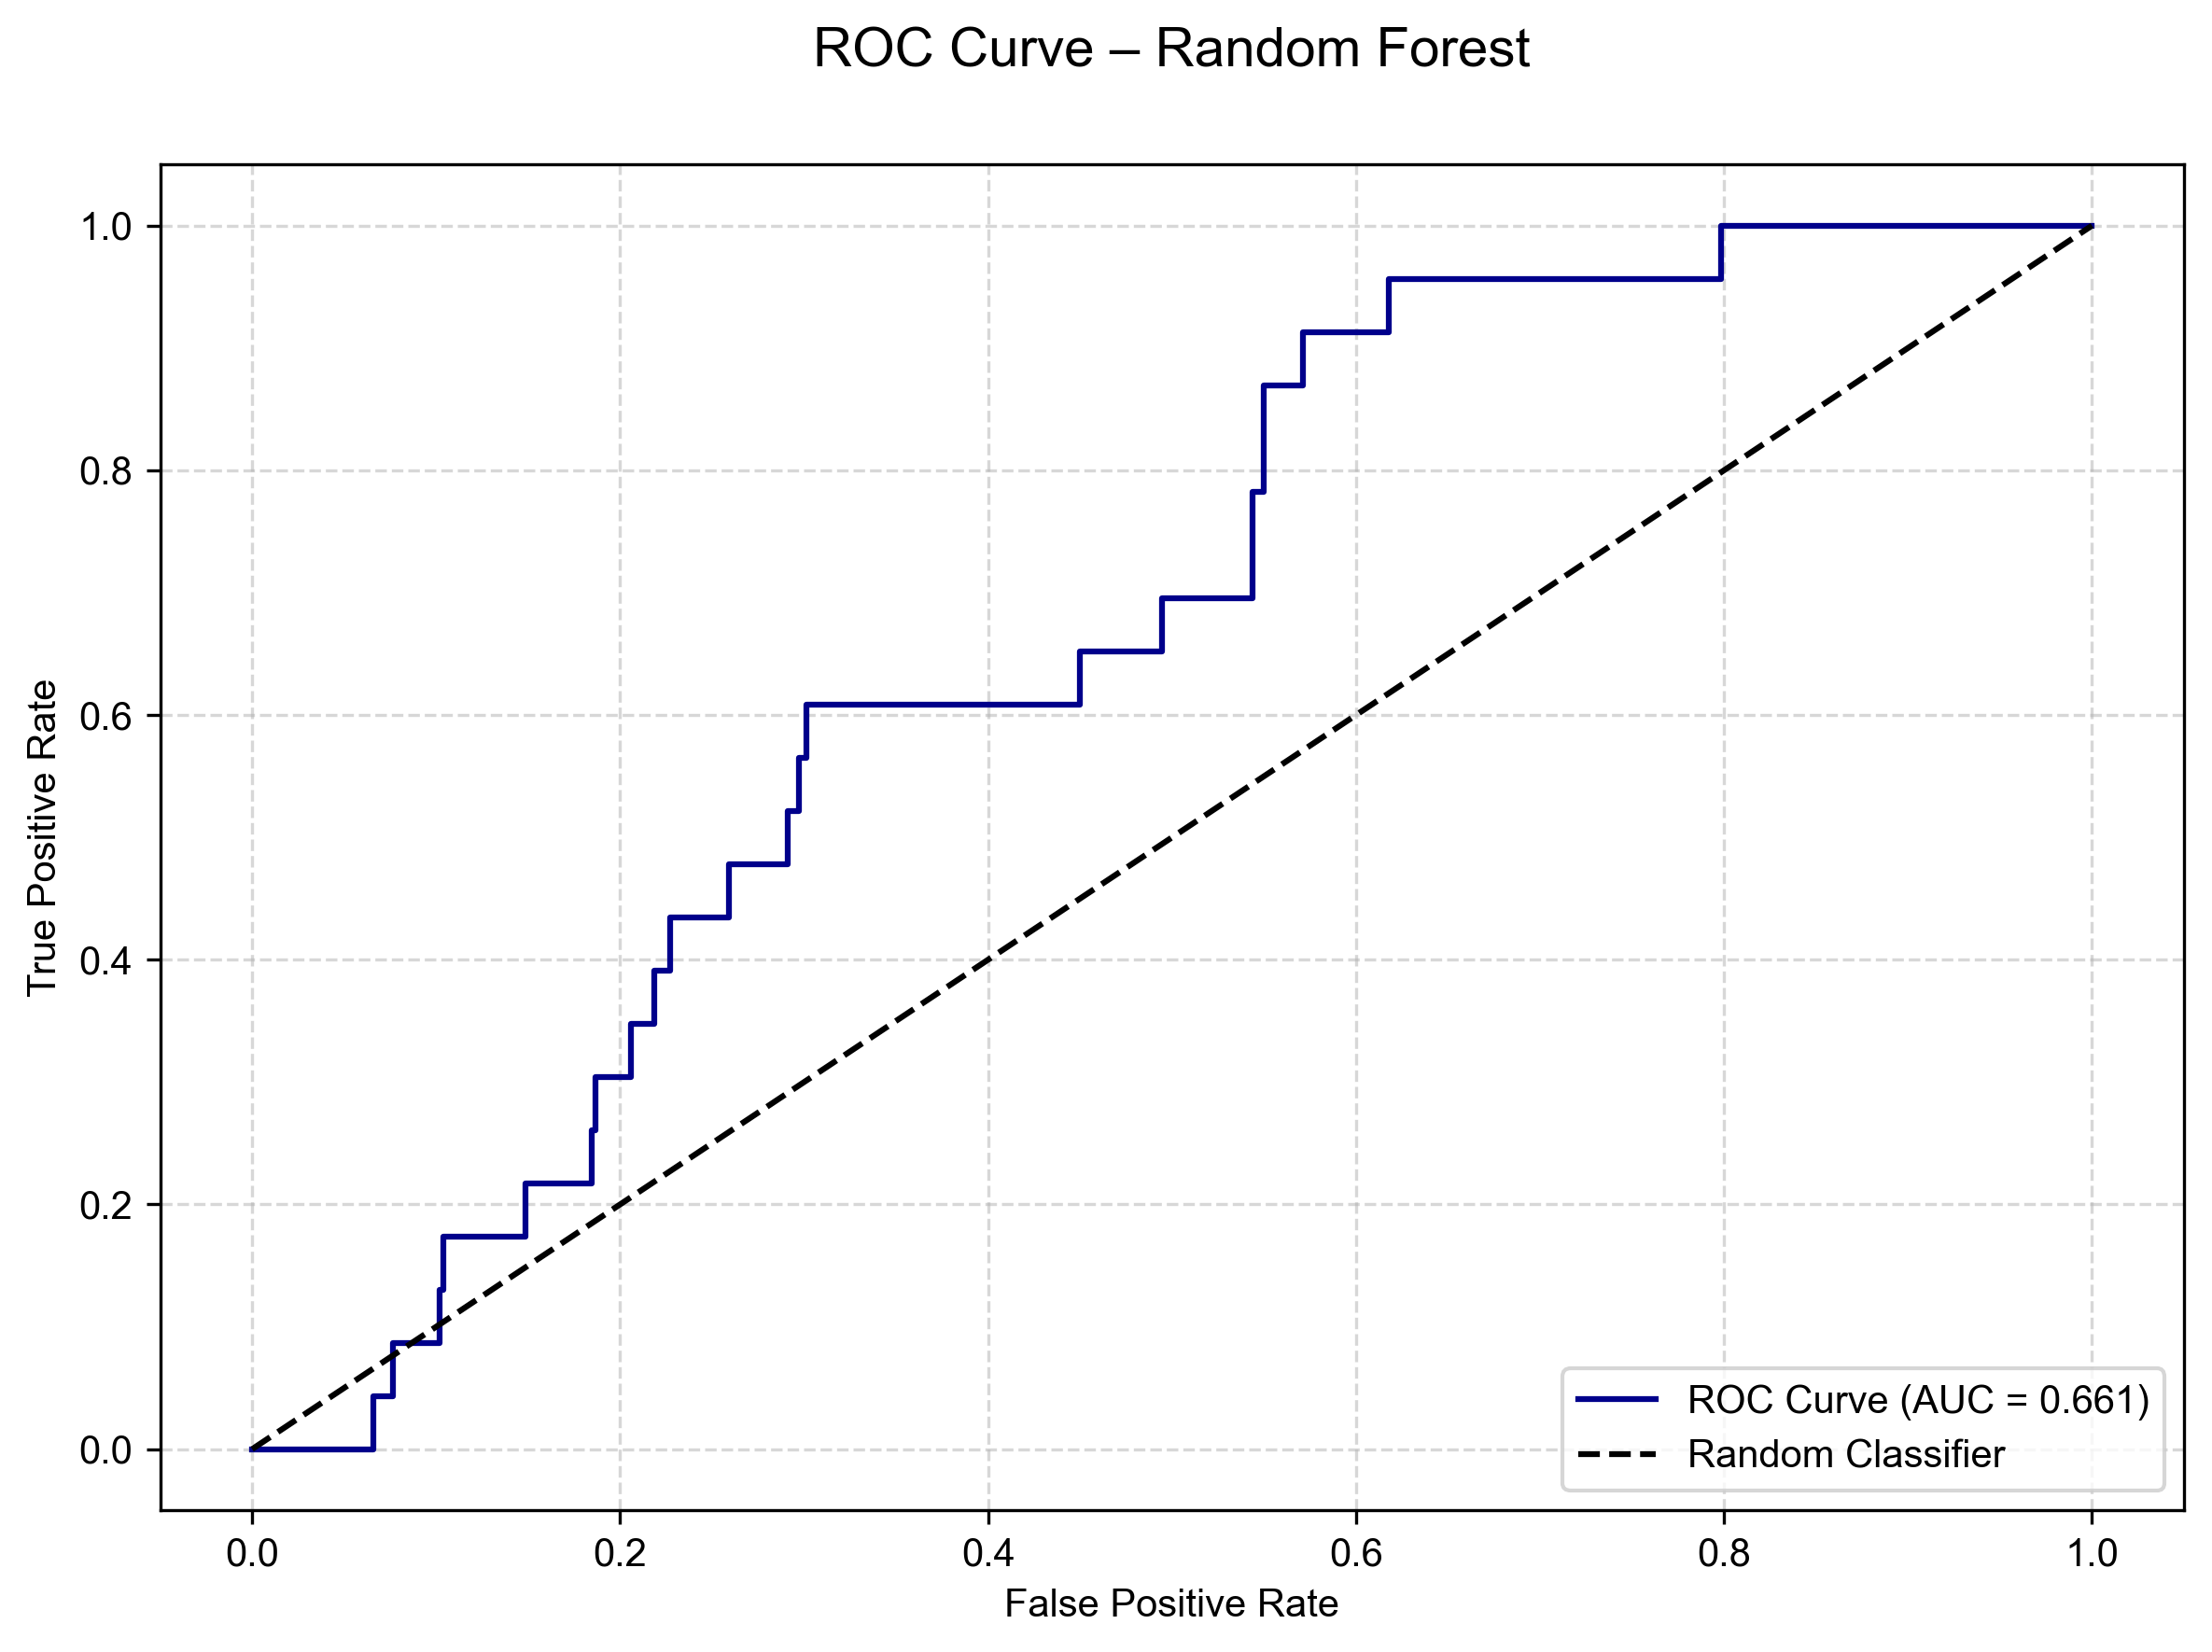

In [16]:
# Version 2: RandomizedSearchCV hyperparameter tuning
# -------------------------------------------
# Train-Test Split
# -------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_filled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Data split completed:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training class ratio: {np.mean(y_train)*100:.1f}% high PME")

# -------------------------------------------
# RandomizedSearchCV Parameter Grid
# -------------------------------------------
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced']
}

rf = RandomForestClassifier(random_state=42)

rs = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# -------------------------------------------
# Fit RandomizedSearchCV
# -------------------------------------------
rs.fit(X_train, y_train)

print(f"Best params: {rs.best_params_}")
rf_model = rs.best_estimator_
print("Random Forest model trained")

# -------------------------------------------
# Evaluation
# -------------------------------------------
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

bal_accuracy = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\nModel Performance:")
print(f"Balanced Accuracy: {bal_accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"True Positive Rate (Recall): {tp / (tp + fn):.3f}")
print(f"False Positive Rate: {fp / (fp + tn):.3f}")

# -------------------------------------------
# SHAP Feature Importance
# -------------------------------------------
print("\nComputing SHAP values...")
np.random.seed(42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_class_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_class_values = shap_values[:, :, 1]
else:
    shap_class_values = shap_values

# Map original feature names to publication labels
rename_map = {
    'sasa_total': 'sasa total',
    'Ghosh-Dill-dG': 'Ghosh-Dill ΔG', 
    'cagiada-dG': 'cagiada ΔG', 
    'Rosetta_best_total_score': 'Rosetta best total score',
    'Villen_halflife_min': 'Tunover kinetics $t_{1/2}$ (min)',
    'mean_molecules_per_cell': 'Molecular Abundance',
    'interacts_with_chaperone': 'Chaperone interaction', 
    'in_complex': 'Complex formation',
    'essential': 'Essential',
    'meltome-melting-point': 'Melting point Tm (°C)', 
    'N_aa_disordered': 'Disordered amino acids', 
    'disorder_fraction': 'Disorder fraction', 
    'mean_plddt': 'Mean plddt'
}
# Prepare display names for SHAP plot - use actual feature names from X_train
feature_names_list = list(X_train.columns)
display_names = [rename_map.get(f, f) for f in feature_names_list]

plt.figure(figsize=(3, 3))
shap.summary_plot(
    shap_class_values,
    X_test,
    feature_names=display_names,
    plot_type='dot',
    max_display=10,
    show=False
)
plt.xlabel('SHAP Value', fontsize=11)
plt.tight_layout()
plt.savefig('SHAP_random_forest10.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

# -------------------------------------------
# Gini Feature Importance
# -------------------------------------------
print("\nRandom Forest Gini-based Feature Importances:")

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': display_names,
    'Gini Importance': importances
}).sort_values(by='Gini Importance', ascending=False)

print(importance_df.to_string(index=False))

# -------------------------------------------
# ROC Data for Origin
# -------------------------------------------
print("\nGenerating comprehensive ROC data for Origin plotting...")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_df = pd.DataFrame({
    'False_Positive_Rate': fpr,
    'True_Positive_Rate': tpr,
    'Threshold': thresholds,
    'Specificity': 1 - fpr,
    'Sensitivity': tpr,
    'Point_Index': range(len(fpr))
})

roc_df['Youden_J'] = roc_df['True_Positive_Rate'] + roc_df['Specificity'] - 1
roc_df['Distance_to_Perfect'] = np.sqrt((fpr - 0)**2 + (tpr - 1)**2)

print("ROC Data Generated:")
print(f"Total data points: {len(roc_df)}")
print(f"AUC Score: {roc_auc:.6f}")
print(f"FPR range: {fpr.min():.6f} to {fpr.max():.6f}")
print(f"TPR range: {tpr.min():.6f} to {tpr.max():.6f}")
print(f"Threshold range: {thresholds.min():.6f} to {thresholds.max():.6f}")

print("\nComplete ROC Data (Copy-Paste Ready for Origin):")
print("# ROC Curve Data")
print("# False_Positive_Rate\tTrue_Positive_Rate\tThreshold\tSpecificity\tSensitivity\tPoint_Index\tYouden_J\tDistance_to_Perfect")

for idx, row in roc_df.iterrows():
    print(
        f"{row['False_Positive_Rate']:.8f}\t"
        f"{row['True_Positive_Rate']:.8f}\t"
        f"{row['Threshold']:.8f}\t"
        f"{row['Specificity']:.8f}\t"
        f"{row['Sensitivity']:.8f}\t"
        f"{row['Point_Index']}\t"
        f"{row['Youden_J']:.8f}\t"
        f"{row['Distance_to_Perfect']:.8f}"
    )

# -------------------------------------------
# ROC Curve Plot
# -------------------------------------------
plt.figure(figsize=(8, 6))
plt.plot(
    roc_df['False_Positive_Rate'],
    roc_df['True_Positive_Rate'],
    label=f'ROC Curve (AUC = {roc_auc:.3f})',
    color='darkblue'
)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
